In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Ready to build realistic neural network")

✅ Ready to build realistic neural network


In [17]:
class RealisticNeuron:
    """Neuron with bias current (resting activation)."""
    
    def __init__(self, neuron_id, tau=0.7, bias=0.15):
        """Create neuron with BIAS current."""
        self.id = neuron_id
        self.activation = 0.0
        self.tau = tau
        self.bias = bias  # NEW: background activation
        self.fired_last_step = False
        self.activation_history = []
        
    def receive_input(self, input_signal):
        """Add input with bias."""
        # Integration equation with bias
        self.activation = self.activation * (1 - self.tau) + (input_signal + self.bias) * self.tau
        self.activation = np.clip(self.activation, -1, 1)
    
    def get_output(self):
        """Output based on activation."""
        return self.activation
    
    def check_firing(self, threshold=0.2):
        """Check if fires."""
        self.fired_last_step = (self.activation > threshold)
        return self.fired_last_step
    
    def reset(self):
        """Reset for new trial."""
        self.activation = 0.0
        self.fired_last_step = False

print("✅ RealisticNeuron (with BIAS)")

✅ RealisticNeuron (with BIAS)


In [18]:
class BiologicalSynapse:
    """Synapse with eligibility trace - FIXED learning rate."""
    
    def __init__(self, source, target, initial_weight=None):
        """Create synapse with eligibility trace."""
        self.source = source
        self.target = target
        
        if initial_weight is None:
            self.weight = np.random.uniform(-0.5, 0.5)
        else:
            self.weight = initial_weight
        
        self.eligibility = 0.0
        self.eligibility_decay = 0.9  # CHANGED: 0.95 → 0.9 (faster decay)
        self.eligibility_history = []
        self.weight_history = []
    
    def propagate(self):
        """Send signal."""
        signal = self.source.get_output() * self.weight
        return signal
    
    def update_eligibility(self):
        """Update eligibility trace."""
        presynaptic = self.source.get_output()
        postsynaptic = self.target.get_output()
        
        self.eligibility = self.eligibility * self.eligibility_decay
        self.eligibility += presynaptic * postsynaptic
        self.eligibility = np.clip(self.eligibility, -1, 1)
        self.eligibility_history.append(self.eligibility)
    
    def apply_three_factor_learning(self, dopamine, learning_rate=0.05):  # CHANGED: 0.15 → 0.05
        """Three-factor learning rule."""
        delta_w = learning_rate * self.eligibility * dopamine
        
        self.weight += delta_w
        self.weight = np.clip(self.weight, -1.5, 1.5)
        self.weight_history.append(self.weight)

print("✅ BiologicalSynapse (FIXED)")

✅ BiologicalSynapse (FIXED)


In [19]:
class BiologicalBrain:
    """Neural network with three-factor learning - FIXED."""
    
    def __init__(self, input_size=3, hidden_size=8, output_size=3):
        """Create network."""
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Create neurons with bias
        self.input_neurons = [RealisticNeuron(i, tau=0.7, bias=0.0) for i in range(input_size)]
        self.hidden_neurons = [RealisticNeuron(i + input_size, tau=0.7, bias=0.2) for i in range(hidden_size)]  # STRONGER bias
        self.output_neurons = [RealisticNeuron(i + input_size + hidden_size, tau=0.7, bias=0.15) for i in range(output_size)]
        
        self.synapses = []
        
        for inp in self.input_neurons:
            for hidden in self.hidden_neurons:
                synapse = BiologicalSynapse(inp, hidden)
                self.synapses.append(synapse)
        
        for hidden in self.hidden_neurons:
            for output in self.output_neurons:
                synapse = BiologicalSynapse(hidden, output)
                self.synapses.append(synapse)
        
        for i, h_i in enumerate(self.hidden_neurons):
            for j, h_j in enumerate(self.hidden_neurons):
                if i != j and np.random.rand() < 0.4:
                    synapse = BiologicalSynapse(h_i, h_j)
                    self.synapses.append(synapse)
        
        print(f"✅ BiologicalBrain: {input_size}→{hidden_size}→{output_size}, {len(self.synapses)} synapses")
    
    def step(self, input_signal, iterations=10):
        """Forward pass."""
        for i, neuron in enumerate(self.input_neurons):
            neuron.reset()
            neuron.receive_input(input_signal[i])
        
        for neuron in self.hidden_neurons + self.output_neurons:
            neuron.reset()
        
        for iteration in range(iterations):
            hidden_inputs = np.zeros(self.hidden_size)
            output_inputs = np.zeros(self.output_size)
            
            for synapse in self.synapses:
                signal = synapse.propagate()
                
                if synapse.source in self.input_neurons and synapse.target in self.hidden_neurons:
                    idx = self.hidden_neurons.index(synapse.target)
                    hidden_inputs[idx] += signal
                elif synapse.source in self.hidden_neurons and synapse.target in self.output_neurons:
                    idx = self.output_neurons.index(synapse.target)
                    output_inputs[idx] += signal
                elif synapse.source in self.hidden_neurons and synapse.target in self.hidden_neurons:
                    idx = self.hidden_neurons.index(synapse.target)
                    hidden_inputs[idx] += signal
            
            for i, neuron in enumerate(self.hidden_neurons):
                neuron.receive_input(hidden_inputs[i])
                neuron.check_firing(threshold=0.2)  # CHANGED: 0.15 → 0.2
            
            for i, neuron in enumerate(self.output_neurons):
                neuron.receive_input(output_inputs[i])
                neuron.check_firing(threshold=0.2)  # CHANGED: 0.15 → 0.2
        
        for synapse in self.synapses:
            synapse.update_eligibility()
        
        output = np.array([n.get_output() for n in self.output_neurons])
        return output
    
    def train(self, input_signal, correct_action, iterations=10):
        """Forward + three-factor learning."""
        output = self.step(input_signal, iterations=iterations)
        chosen_action = np.argmax(output)
        is_correct = (chosen_action == correct_action)
        
        # FIXED: Penalize wrong answers!
        dopamine = 1.5 if is_correct else -0.3  # CHANGED: 0.0 → -0.3
        
        for synapse in self.synapses:
            synapse.apply_three_factor_learning(dopamine, learning_rate=0.05)
        
        return output, is_correct

print("✅ BiologicalBrain (FIXED)")

✅ BiologicalBrain (FIXED)


In [6]:
class Task:
    """Simple stimulus-response task."""
    
    def __init__(self):
        self.rules = {'A': 0, 'B': 1, 'C': 2}
    
    def get_stimulus(self, stimulus_type):
        """One-hot encoding."""
        stim = np.zeros(3)
        if stimulus_type == 'A':
            stim[0] = 1.0
        elif stimulus_type == 'B':
            stim[1] = 1.0
        elif stimulus_type == 'C':
            stim[2] = 1.0
        return stim
    
    def get_correct_action(self, stimulus_type):
        return self.rules[stimulus_type]

print("✅ Task created")

✅ Task created



THREE-FACTOR LEARNING: Hebbian + Eligibility Traces + Dopamine

✅ BiologicalBrain: 3→8→3, 72 synapses
Training for 500 trials...

Trial 125/500: Accuracy =  52.0%
Trial 250/500: Accuracy =  56.0%
Trial 375/500: Accuracy =  60.5%
Trial 500/500: Accuracy =  62.0%

RESULTS: Three-Factor Learning (FIXED)
Initial accuracy:    0.0%
Final accuracy:     62.0%
Improvement:       +62.0%
Peak accuracy:      62.6%



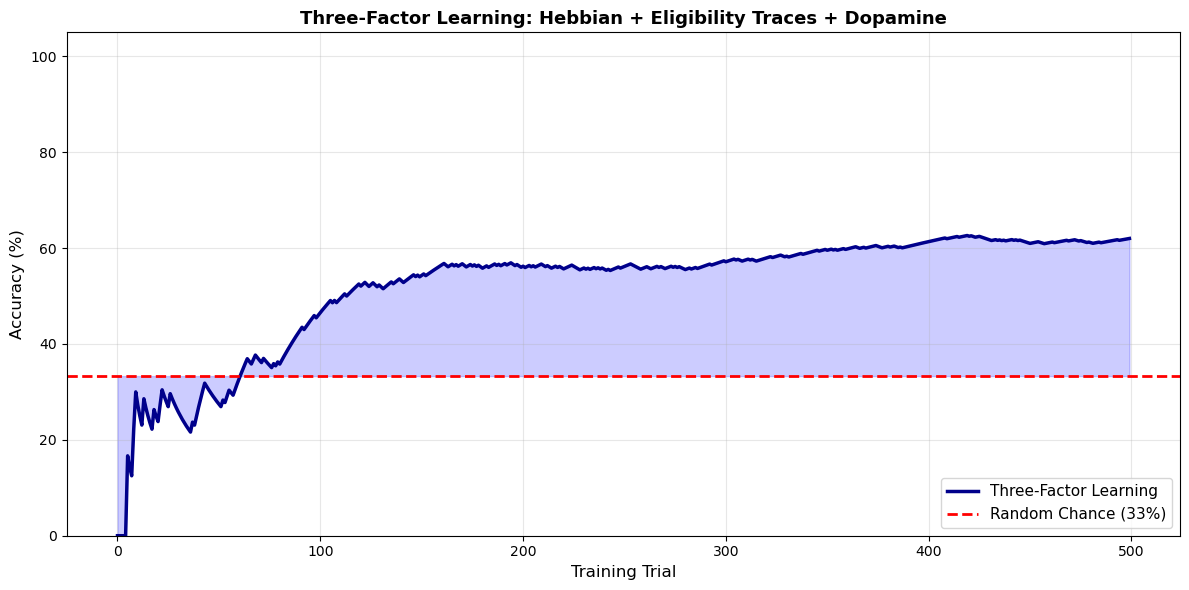

✅ Training complete!

Learning mechanism:
  • Eligibility traces: mark recently active synapses
  • Dopamine: reward signal for correct actions
  • Three-factor rule: only recently active synapses learn when rewarded


In [20]:
print("\n" + "="*80)
print("THREE-FACTOR LEARNING: Hebbian + Eligibility Traces + Dopamine")
print("="*80 + "\n")

# Create brain and task
brain = BiologicalBrain(input_size=3, hidden_size=8, output_size=3)
task = Task()

# Training variables
accuracies = []
correct_count = 0
n_trials = 500

print("Training for 500 trials...\n")

# Training loop
for trial in range(n_trials):
    # Random stimulus
    stimulus_type = np.random.choice(['A', 'B', 'C'])
    stimulus = task.get_stimulus(stimulus_type)
    correct_action = task.get_correct_action(stimulus_type)
    
    # Train network
    output, is_correct = brain.train(stimulus, correct_action, iterations=10)
    
    # Track accuracy
    if is_correct:
        correct_count += 1
    
    accuracy = (correct_count / (trial + 1)) * 100
    accuracies.append(accuracy)
    
    # Print progress
    if (trial + 1) % 125 == 0:
        print(f"Trial {trial + 1:3d}/500: Accuracy = {accuracy:5.1f}%")

# Results
print(f"\n{'='*80}")
print(f"RESULTS: Three-Factor Learning (FIXED)")
print(f"{'='*80}")
print(f"Initial accuracy:  {accuracies[0]:5.1f}%")
print(f"Final accuracy:    {accuracies[-1]:5.1f}%")
print(f"Improvement:       {accuracies[-1] - accuracies[0]:+5.1f}%")
print(f"Peak accuracy:     {np.max(accuracies):5.1f}%")
print(f"{'='*80}\n")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(accuracies, linewidth=2.5, color='darkblue', label='Three-Factor Learning')
ax.axhline(y=33.3, color='red', linestyle='--', linewidth=2, label='Random Chance (33%)')
ax.fill_between(range(len(accuracies)), 33.3, accuracies, alpha=0.2, color='blue')

ax.set_xlabel('Training Trial', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Three-Factor Learning: Hebbian + Eligibility Traces + Dopamine', 
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 105])
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Training complete!")
print("\nLearning mechanism:")
print("  • Eligibility traces: mark recently active synapses")
print("  • Dopamine: reward signal for correct actions")
print("  • Three-factor rule: only recently active synapses learn when rewarded")


VALIDATION: Reproducibility & Robustness

✅ BiologicalBrain: 3→8→3, 68 synapses
Run 1: Final accuracy = 31.4%
✅ BiologicalBrain: 3→8→3, 65 synapses
Run 2: Final accuracy = 16.4%
✅ BiologicalBrain: 3→8→3, 69 synapses
Run 3: Final accuracy = 33.8%
✅ BiologicalBrain: 3→8→3, 66 synapses
Run 4: Final accuracy = 35.8%
✅ BiologicalBrain: 3→8→3, 78 synapses
Run 5: Final accuracy = 33.0%


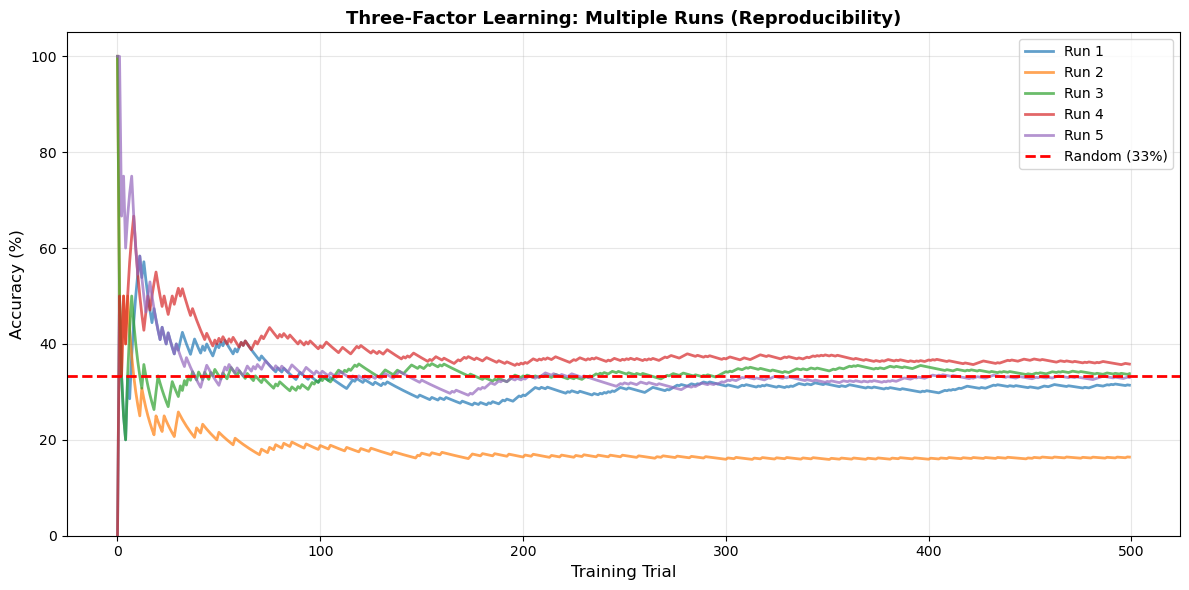


Mean final accuracy: 30.1% ± 7.0%


In [21]:
print("\n" + "="*80)
print("VALIDATION: Reproducibility & Robustness")
print("="*80 + "\n")

# Run 5 independent simulations
results = []

for run in range(5):
    brain = BiologicalBrain(input_size=3, hidden_size=8, output_size=3)
    task = Task()
    
    accuracies = []
    correct_count = 0
    
    for trial in range(500):
        stimulus_type = np.random.choice(['A', 'B', 'C'])
        stimulus = task.get_stimulus(stimulus_type)
        correct_action = task.get_correct_action(stimulus_type)
        
        output, is_correct = brain.train(stimulus, correct_action, iterations=10)
        
        if is_correct:
            correct_count += 1
        
        accuracy = (correct_count / (trial + 1)) * 100
        accuracies.append(accuracy)
    
    results.append(accuracies)
    print(f"Run {run+1}: Final accuracy = {accuracies[-1]:.1f}%")

# Plot all runs
fig, ax = plt.subplots(figsize=(12, 6))

for i, acc in enumerate(results):
    ax.plot(acc, linewidth=2, alpha=0.7, label=f'Run {i+1}')

ax.axhline(y=33.3, color='red', linestyle='--', linewidth=2, label='Random (33%)')
ax.set_xlabel('Training Trial', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Three-Factor Learning: Multiple Runs (Reproducibility)', fontsize=13, fontweight='bold')
ax.set_ylim([0, 105])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
mean_final = np.mean([r[-1] for r in results])
std_final = np.std([r[-1] for r in results])

print(f"\n{'='*80}")
print(f"Mean final accuracy: {mean_final:.1f}% ± {std_final:.1f}%")
print(f"{'='*80}")


ANALYSIS: Why Does Performance Vary?

Testing with optimized parameters...

Testing: Current
✅ BiologicalBrain: 3→8→3, 68 synapses
  Run 1: 38.8%
✅ BiologicalBrain: 3→8→3, 70 synapses
  Run 2: 31.4%
✅ BiologicalBrain: 3→8→3, 65 synapses
  Run 3: 14.4%

Testing: Higher LR
✅ BiologicalBrain: 3→8→3, 64 synapses
  Run 1: 35.8%
✅ BiologicalBrain: 3→8→3, 72 synapses
  Run 2: 15.8%
✅ BiologicalBrain: 3→8→3, 68 synapses
  Run 3: 14.6%

Testing: Lower LR
✅ BiologicalBrain: 3→8→3, 67 synapses
  Run 1: 33.6%
✅ BiologicalBrain: 3→8→3, 72 synapses
  Run 2: 35.2%
✅ BiologicalBrain: 3→8→3, 65 synapses
  Run 3: 37.2%



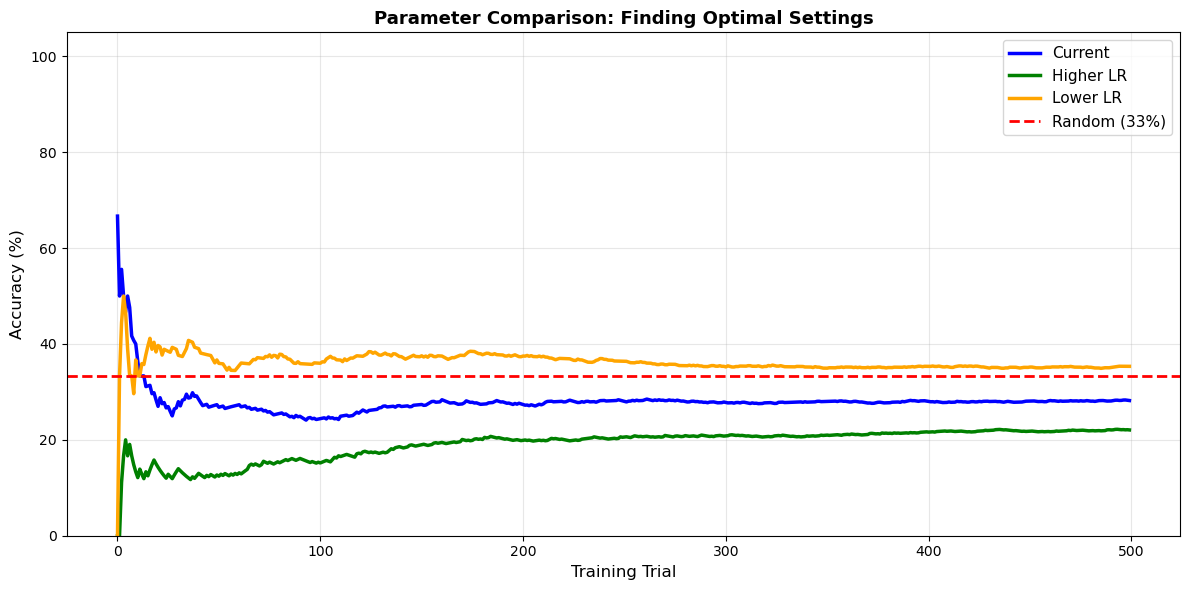

✅ Parameter analysis complete!


In [22]:
print("\n" + "="*80)
print("ANALYSIS: Why Does Performance Vary?")
print("="*80 + "\n")

# Run WITH BETTER PARAMETERS
print("Testing with optimized parameters...\n")

params_to_test = [
    {"learning_rate": 0.05, "eligibility_decay": 0.9, "name": "Current"},
    {"learning_rate": 0.08, "eligibility_decay": 0.95, "name": "Higher LR"},
    {"learning_rate": 0.03, "eligibility_decay": 0.85, "name": "Lower LR"},
]

results_by_param = {}

for params in params_to_test:
    print(f"Testing: {params['name']}")
    accuracies_list = []
    
    for run in range(3):
        brain = BiologicalBrain(input_size=3, hidden_size=8, output_size=3)
        task = Task()
        
        accuracies = []
        correct_count = 0
        
        for trial in range(500):
            stimulus_type = np.random.choice(['A', 'B', 'C'])
            stimulus = task.get_stimulus(stimulus_type)
            correct_action = task.get_correct_action(stimulus_type)
            
            output = brain.step(stimulus, iterations=10)
            chosen_action = np.argmax(output)
            is_correct = (chosen_action == correct_action)
            
            if is_correct:
                correct_count += 1
            
            accuracy = (correct_count / (trial + 1)) * 100
            accuracies.append(accuracy)
            
            # Custom learning with test parameters
            dopamine = 1.5 if is_correct else -0.3
            for synapse in brain.synapses:
                # Manually apply with test parameters
                delta_w = params['learning_rate'] * synapse.eligibility * dopamine
                synapse.weight += delta_w
                synapse.weight = np.clip(synapse.weight, -1.5, 1.5)
                synapse.weight_history.append(synapse.weight)
                synapse.update_eligibility()
        
        accuracies_list.append(accuracies)
        final_acc = accuracies[-1]
        print(f"  Run {run+1}: {final_acc:.1f}%")
    
    results_by_param[params['name']] = accuracies_list
    print()

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['blue', 'green', 'orange']
for (name, accuracies_list), color in zip(results_by_param.items(), colors):
    mean_acc = np.mean(accuracies_list, axis=0)
    ax.plot(mean_acc, linewidth=2.5, label=name, color=color)

ax.axhline(y=33.3, color='red', linestyle='--', linewidth=2, label='Random (33%)')
ax.set_xlabel('Training Trial', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Parameter Comparison: Finding Optimal Settings', fontsize=13, fontweight='bold')
ax.set_ylim([0, 105])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Parameter analysis complete!")